# Multiple Linear Regression From Scratch Using OLS

This notebook implements Multiple Linear Regression from scratch
using the Ordinary Least Squares (OLS) method.

### Objective

- Represent Multiple Linear Regression in matrix form
- Implement the OLS solution using NumPy
- Fit the model without using sklearn's LinearRegression
- Generate predictions
- Evaluate the model using regression metrics

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/Advertising.csv")

# We just changed our df by not taking the unnamed Id column as it was not helpful
df = df.iloc[:, 1:]
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
df.shape

(200, 4)

In [6]:
X = df.drop(columns=["Sales"]).values
y = df["Sales"].values

In [8]:
X.shape, y.shape

((200, 3), (200,))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
X_train.shape, X_test.shape

((160, 3), (40, 3))

## Ordinary Least Squares

Multiple Linear Regression can be represented in matrix form as:

Ŷ = Xβ

where:

- X = feature/design matrix
- β = vector of model coefficients
- Ŷ = target vector
- y = actual values vector

The Ordinary Least Squares estimate of β is:

β = (XᵀX)⁻¹Xᵀy

The intercept is included by adding a column of ones to X.

In [18]:
# Now this is out X matrix or design matrix where we have added every x in the row of X and also added 1 in front of the x values
X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_train_b.shape

(160, 4)

In [19]:
# We have calculated the XᵀX matrix
XTX = X_train_b.T @ X_train_b

XTX.shape

(4, 4)

In [22]:
# We have calculated the Xᵀy matrix
XTy = X_train_b.T @ y_train

XTy.shape

(4,)

In [26]:
beta = np.linalg.inv(XTX) @ XTy

beta

array([2.97906734e+00, 4.47295175e-02, 1.89195054e-01, 2.76111434e-03])

In [30]:
intercept = beta[0]
coefficients = beta[1:]

print("Intercept: ", intercept)
print("Coefficient: ", coefficient)

Intercept:  2.9790673381226327
Coefficient:  [0.04472952 0.18919505 0.00276111]


In [35]:
coefficients_df = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Coefficient": coefficients
})

coefficients_df

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


$$
\hat{Sales}
=
\beta_0
+
\beta_1(TV)
+
\beta_2(Radio)
+
\beta_3(Newspaper)
$$

In [38]:
X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]

X_test_b.shape

(40, 4)

In [64]:
y_pred = X_test_b @ beta

y_pred[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

In [65]:
y_test[:10]

array([16.9, 22.4, 21.4,  7.3, 24.7, 12.6, 22.3,  8.4, 11.5, 14.9])

In [66]:
y_pred.shape

(40,)

In [67]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

mae_value = mae(y_test, y_pred)

print("MAE: ", mae_value)

MAE:  1.4607567168117612


In [68]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

mse_value = mse(y_test, y_pred)

print("MSE: ", mse_value)

MSE:  3.1740973539761073


In [69]:
def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

rmse_value = rmse(y_test, y_pred)

print("RMSE: ", rmse_value)

RMSE:  1.781599661533451


In [70]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

r2_value = r2_score(y_test, y_pred)

print("R²: ", r2_value)

R²:  0.8994380241009119


In [71]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae_value, mse_value, rmse_value, r2_value]
})

metrics

,Metric,Value
0,MAE,1.460757
1,MSE,3.174097
2,RMSE,1.781600
3,R²,0.899438


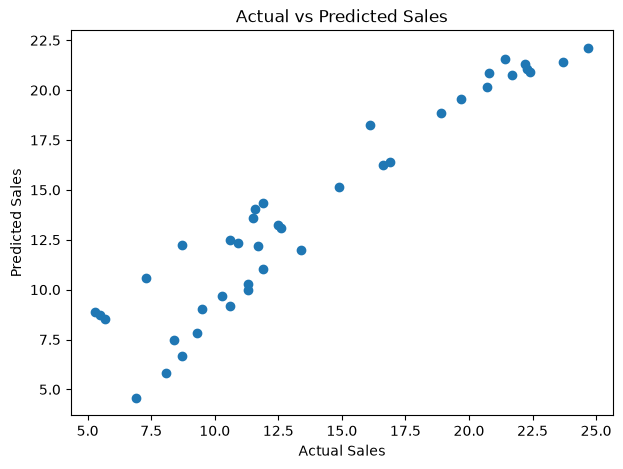

In [72]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

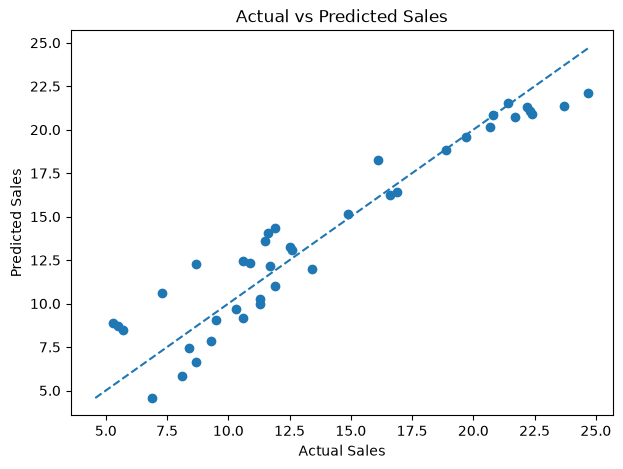

In [73]:
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [74]:
residuals = y_test - y_pred

In [75]:
residuals[:10]

array([ 0.4919758 ,  1.51011791, -0.15384318, -3.30850256,  2.58762674,
       -0.50559172,  1.24280808,  0.93898966, -2.10634581, -0.25506967])

In [77]:
print("Mean residual: ", np.mean(residuals))

Mean residual:  -0.09752119905509149


## Coefficient Interpretation

Each coefficient represents the expected change in Sales
for a one-unit increase in that predictor, while holding
the other predictors constant.

- TV coefficient: effect of TV advertising while holding Radio and Newspaper constant.
- Radio coefficient: effect of Radio advertising while holding TV and Newspaper constant.
- Newspaper coefficient: effect of Newspaper advertising while holding TV and Radio constant.

## Conclusion

Multiple Linear Regression was implemented from scratch
using the Ordinary Least Squares matrix formulation.

The implementation:

- Constructs the design matrix with an intercept.
- Estimates coefficients using the OLS solution.
- Generates predictions for unseen test data.
- Evaluates predictions using MAE, MSE, RMSE, and R².
- Provides interpretable coefficients for the three advertising features.

The implementation will be independently validated against
scikit-learn in the next notebook.